# M5.2 · NeMo Curator

End-to-end **CPT corpus curation** on a miniature compliance corpus. Run code cells **1 → 13** in order.

## Section 1 — Environment & prerequisites

Bootstraps a per-notebook **uv** virtualenv (`.venv/`) and installs `nemo-curator`, `fasttext`, and cuDF/RAPIDS via `notebook_env.py` + `uv pip`.

### Code Cell 1 — Bootstrap uv env & install prerequisites

Creates/reuses `.venv`, installs missing packages. Restart kernel once if cuDF was just installed.

In [1]:
# Code Cell 1 — Bootstrap uv env & install prerequisites
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from notebook_env import bootstrap_notebook_env, ensure

bootstrap_notebook_env()
ensure("nemo_curator", ["nemo-curator"])
ensure("fasttext", ["fasttext-wheel"])
ensure(
    "cudf",
    ["nemo-curator[deduplication_cuda12]"],
    extra_index="https://pypi.nvidia.com",
    quiet=True,
)
print("\nPrerequisites ready. If cudf was just installed, RESTART THE KERNEL once, then re-run.")


notebook env: /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/.venv (python /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/.venv/bin/python)
ok: nemo_curator
ok: fasttext
ok: cudf

Prerequisites ready. If cudf was just installed, RESTART THE KERNEL once, then re-run.


### Code Cell 2 — Verify GPU availability

Asserts CUDA GPU is present (required for exact/fuzzy dedup phases).

In [2]:
# Code Cell 2 — Verify GPU availability
import torch

assert torch.cuda.is_available(), (
    "No CUDA GPU detected. The exact/fuzzy dedup phases need a GPU. Attach a GPU and re-run."
)
_p = torch.cuda.get_device_properties(0)
print(f"GPU: {_p.name} ({_p.total_memory / 2**30:.1f} GiB) | CUDA {torch.version.cuda}")


GPU: NVIDIA A100 80GB PCIe (79.3 GiB) | CUDA 12.8


## Section 2 — Paths & Ray cluster

Sets directory layout and starts Ray. TEXT_CLEAN uses **batch mode** (Code Cell 8) to avoid CPU reservation errors on ~11-CPU workshop VMs.

### Code Cell 3 — Define paths & create directories

In [3]:
# Code Cell 3 — Define paths & create directories
import json, shutil, urllib.request
from pathlib import Path

NB_DIR = Path.cwd().resolve()
RAW_DIR = NB_DIR / "data" / "raw"
WORK = NB_DIR / "work"
STAGES = WORK / "stages"
CURATED_DIR = NB_DIR / "data" / "final" / "cpt"
LID_PATH = WORK / "models" / "lid.176.bin"
SUMMARY_PATH = WORK / "summary.json"
for d in (WORK, STAGES, CURATED_DIR, LID_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

assert any(RAW_DIR.rglob("*.jsonl")), (
    f"No raw data under {RAW_DIR}. Run `python seed_raw_corpus.py` from this folder first."
)
print("raw   :", RAW_DIR)
print("curated:", CURATED_DIR)


raw   : /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/data/raw
curated: /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/data/final/cpt


### Code Cell 4 — Start Ray client

Starts local Ray. `NUM_CPUS` defaults to machine CPU count; override with `RAY_NUM_CPUS`.

In [4]:
# Code Cell 4 — Start Ray client
import os

from nemo_curator.core.client import RayClient

NUM_CPUS = int(os.environ.get("RAY_NUM_CPUS", os.cpu_count() or 11))
ray_client = RayClient(num_cpus=NUM_CPUS)
ray_client.start()
print(f"Ray client started (num_cpus={NUM_CPUS})")


/home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-09 15:25:32,054	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-06-09 15:25:32.140 | WARNING  | nemo_curator.core.client:start:121 - No monitoring services are running. Please run the `start_prometheus_grafana.py` script from nemo_curator/metrics folder to setup monitoring services separately.
2026-06-09 15:25:32.171 | INFO     | nemo_curator.core.utils:init_cluster:185 - Ray start command: ray start --head --node-ip-address 172.27.28.197 --port 6379 --metrics-export-port 8080 --dashboard-host 127.0.0.1 --dashboard-port 8265 --ray-client-server-port 10001 --temp-dir /tmp/ray -

2026-06-09 15:25:32,679	INFO usage_lib.py:448 -- Usage stats collection is disabled.
2026-06-09 15:25:32,679	INFO scripts.py:940 -- Local node IP: 172.27.28.197
2026-06-09 15:25:35,575	SUCC scripts.py:979 -- --------------------
2026-06-09 15:25:35,575	SUCC scripts.py:980 -- Ray runtime started.
2026-06-09 15:25:35,575	SUCC scripts.py:981 -- --------------------
2026-06-09 15:25:35,575	INFO scripts.py:983 -- Next steps
2026-06-09 15:25:35,575	INFO scripts.py:986 -- To add another node to this Ray cluster, run
2026-06-09 15:25:35,575	INFO scripts.py:989 --   ray start --address='172.27.28.197:6379'
2026-06-09 15:25:35,575	INFO scripts.py:1000 -- To connect to this Ray cluster:
2026-06-09 15:25:35,576	INFO scripts.py:1002 -- import ray
2026-06-09 15:25:35,576	INFO scripts.py:1003 -- ray.init(_node_ip_address='172.27.28.197')
2026-06-09 15:25:35,576	INFO scripts.py:1017 -- To submit a Ray job using the Ray Jobs CLI:
2026-06-09 15:25:35,576	INFO scripts.py:1018 --   RAY_API_SERVER_ADDRESS=

## Section 3 — Phase 0: INGEST

### Code Cell 5 — INGEST raw JSONL

In [5]:
# Code Cell 5 — INGEST raw JSONL
STAGE_STATS = []

def _count(d):
    return sum(1 for p in Path(d).rglob("*.jsonl") for ln in p.read_text().splitlines() if ln.strip())

ingest_dir = STAGES / "00_ingest"
if ingest_dir.exists():
    shutil.rmtree(ingest_dir)
ingest_dir.mkdir(parents=True)

LAYER_DIRS = ("level_1", "level_2")
n_in = 0
for layer in LAYER_DIRS:
    layer_dir = RAW_DIR / layer
    if not layer_dir.exists():
        continue
    for src in sorted(layer_dir.glob("*.jsonl")):
        out_rows = []
        for line in src.read_text().splitlines():
            if not line.strip():
                continue
            rec = json.loads(line)
            n_in += 1
            text = rec.get("content") or rec.get("text") or ""
            if not text:
                continue
            out = {"text": text, "source": rec.get("source", src.stem), "layer": layer}
            if "id" in rec:
                out["id"] = rec["id"]
            out_rows.append(out)
        (ingest_dir / f"{layer}__{src.name}").write_text(
            "".join(json.dumps(r) + "\n" for r in out_rows)
        )
n_ingest = _count(ingest_dir)
STAGE_STATS.append(("0 INGEST", n_ingest))
print(f"INGEST: read {n_in} lines -> {n_ingest} records under {ingest_dir}")


INGEST: read 600 lines -> 600 records under /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/work/stages/00_ingest


## Section 4 — Phase 1: TEXT_CLEAN (batch mode)

### Code Cell 6 — TEXT_CLEAN: imports, modifiers & filter helpers

In [6]:
# Code Cell 6 — TEXT_CLEAN: imports, modifiers & filter helpers
import ast, re, unicodedata
from collections import Counter
from functools import partial

from nemo_curator.pipeline import Pipeline
from nemo_curator.stages.text.io.reader.jsonl import JsonlReader
from nemo_curator.stages.text.io.writer.jsonl import JsonlWriter
from nemo_curator.stages.text.modules import AddId
from nemo_curator.stages.text.modifiers import Modify, DocumentModifier
from nemo_curator.stages.text.filters import Filter, ScoreFilter
from nemo_curator.stages.text.filters.heuristic.string import (
    NonAlphaNumericFilter, WordCountFilter, CommonEnglishWordsFilter,
)
from nemo_curator.stages.text.filters.heuristic.repetition.repetition import RepeatedLinesFilter
from nemo_curator.stages.text.filters.fasttext.fasttext_filters import FastTextLangId


class FixBytesReprModifier(DocumentModifier):
    def modify_document(self, text):
        if not text or not (text[:2] in ("b'", 'b"') and text.endswith(text[1])):
            return text
        try:
            parsed = ast.literal_eval(text)
        except (SyntaxError, ValueError):
            return text
        return parsed.decode("utf-8", "replace") if isinstance(parsed, bytes) else text


class HTMLStripper(DocumentModifier):
    _tag = re.compile(r"<[^>]+>")
    def modify_document(self, text):
        if not text:
            return ""
        text = self._tag.sub(" ", text)
        for a, b in (("&amp;", "&"), ("&lt;", "<"), ("&gt;", ">"), ("&quot;", '"'), ("&nbsp;", " ")):
            text = text.replace(a, b)
        return text


class EnglishTextCleaner(DocumentModifier):
    _ws = re.compile(r"[ \t\f\v]+")
    _nl = re.compile(r"\n{3,}")
    _ctl = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]")
    def modify_document(self, text):
        if not text:
            return ""
        text = unicodedata.normalize("NFC", text).replace("\r\n", "\n").replace("\r", "\n")
        text = self._ctl.sub(" ", text)
        text = self._ws.sub(" ", text)
        return self._nl.sub("\n\n", text).strip()


BOILERPLATE_DENYLIST = {
    "fincen_advisory": ["FinCEN Advisory FIN-2020-A001"],
    "ffiec_bsa": ["Page 1 of 5", "For more information visit www.ffiec.gov"],
}


class BoilerplateLineRemover(DocumentModifier):
    def __init__(self, denylist_by_source):
        super().__init__()
        self._deny = {k: set(v) for k, v in denylist_by_source.items()}
    def modify_document(self, text, source):
        strip = self._deny.get(source)
        if not text or not strip:
            return text or ""
        return "\n".join(ln for ln in text.splitlines() if ln.strip() not in strip)


_PII = [
    (re.compile(r"\b\d{3}-\d{2}-\d{4}\b"), "[SSN]"),
    (re.compile(r"\b(?:\d{4}[ \-]){3}\d{4}\b"), "[CREDIT_CARD]"),
    (re.compile(r"\b[A-Z]{2}\d{2}[A-Z0-9]{11,30}\b"), "[IBAN]"),
    (re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"), "[EMAIL]"),
    (re.compile(r"(?:\+?\d{1,2}[\s.-]?)?\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}\b"), "[PHONE]"),
    (re.compile(r"\b\d{2}-\d{7}\b"), "[EIN]"),
]


class PiiTagRedactor(DocumentModifier):
    def modify_document(self, text):
        if not text:
            return ""
        for pat, tag in _PII:
            text = pat.sub(tag, text)
        return text


def is_target_lang(lang_id_value, target_code="EN"):
    v = lang_id_value
    if isinstance(v, (list, tuple)) and len(v) == 2:
        return str(v[1]).upper() == target_code
    if isinstance(v, str):
        try:
            p = ast.literal_eval(v)
            if isinstance(p, (list, tuple)) and len(p) == 2:
                return str(p[1]).upper() == target_code
        except Exception:
            return target_code in v.upper()
    return False


def length_in_range(text, lo=200, hi=None):
    n = len(text or "")
    return n >= lo and (hi is None or n <= hi)


### Code Cell 7 — Download FastText language-id model

In [7]:
# Code Cell 7 — Download FastText language-id model
if not LID_PATH.exists():
    print("Downloading fastText lid.176.bin (~130 MB)...")
    urllib.request.urlretrieve(
        "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin",
        str(LID_PATH),
    )
print("lid model:", LID_PATH)


lid model: /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/work/models/lid.176.bin


### Code Cell 8 — Run TEXT_CLEAN pipeline (batch mode)

Runs with `XennaExecutor(execution_mode="batch")` — one stage at a time, safe on ~11-CPU boxes.

In [8]:
# Code Cell 8 — Run TEXT_CLEAN pipeline (batch mode)
from nemo_curator.backends.xenna import XennaExecutor

EXECUTOR = XennaExecutor(config={"execution_mode": "batch"})

clean_dir = STAGES / "01_clean"
if clean_dir.exists():
    shutil.rmtree(clean_dir)

MIN_CHARS = 40

pipeline = Pipeline(
    name="cpt_text_clean",
    description="bytes->html->clean->lang->length->addid->quality->boilerplate->pii",
    stages=[
        JsonlReader(file_paths=str(ingest_dir), fields=["text", "source", "layer", "id"]),
        Modify(modifier_fn=FixBytesReprModifier(), input_fields="text"),
        Modify(modifier_fn=HTMLStripper(), input_fields="text"),
        Modify(modifier_fn=EnglishTextCleaner(), input_fields="text"),
        ScoreFilter(filter_obj=FastTextLangId(model_path=str(LID_PATH), min_langid_score=0.30),
                    text_field="text", score_field="lang_id"),
        Filter(filter_fn=partial(is_target_lang, target_code="EN"), filter_field="lang_id"),
        Filter(filter_fn=partial(length_in_range, lo=MIN_CHARS, hi=None), filter_field="text"),
        AddId(id_field="id", id_prefix="cpt", overwrite=True),
        ScoreFilter(filter_obj=NonAlphaNumericFilter(max_non_alpha_numeric_to_text_ratio=0.30),
                    text_field="text", score_field="non_alpha_ratio"),
        ScoreFilter(filter_obj=RepeatedLinesFilter(max_repeated_line_fraction=0.70),
                    text_field="text", score_field="repeated_line_frac"),
        ScoreFilter(filter_obj=CommonEnglishWordsFilter(min_num_common_words=2),
                    text_field="text", score_field="common_words"),
        Modify(modifier_fn=BoilerplateLineRemover(BOILERPLATE_DENYLIST),
               input_fields=[["text", "source"]], output_fields="text"),
        Modify(modifier_fn=PiiTagRedactor(), input_fields="text"),
        JsonlWriter(path=str(clean_dir)),
    ],
)
pipeline.run(executor=EXECUTOR)
n_clean = _count(clean_dir)
STAGE_STATS.append(("1 TEXT_CLEAN", n_clean))
print(f"TEXT_CLEAN: {n_clean} records -> {clean_dir}")


2026-06-09 15:25:39.732 | INFO     | nemo_curator.pipeline.pipeline:build:70 - Planning pipeline: cpt_text_clean
2026-06-09 15:25:39.733 | INFO     | nemo_curator.pipeline.pipeline:_decompose_stages:106 - Decomposing composite stage: jsonl_reader
2026-06-09 15:25:39.734 | INFO     | nemo_curator.pipeline.pipeline:_decompose_stages:120 - Expanded 'jsonl_reader' into 2 execution stages
2026-06-09 15:25:39.736 | INFO     | nemo_curator.backends.xenna.executor:execute:135 - Execution mode: BATCH
2026-06-09 15:25:39,736	INFO worker.py:1672 -- Using address 172.27.28.197:6379 set in the environment variable RAY_ADDRESS
2026-06-09 15:25:39,739	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 172.27.28.197:6379...
2026-06-09 15:25:39,759	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
/home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/.venv/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: 

TEXT_CLEAN: 211 records -> /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/work/stages/01_clean


## Section 5 — Phase 2: EXACT_DEDUP (SHA-256, GPU)

### Code Cell 9 — EXACT_DEDUP (identify + remove)

In [9]:
# Code Cell 9 — EXACT_DEDUP (identify + remove)
from nemo_curator.stages.deduplication.exact.workflow import ExactDeduplicationWorkflow
from nemo_curator.stages.text.deduplication.removal_workflow import TextDuplicatesRemovalWorkflow

exact_out = STAGES / "02_exact"
exact_ids = WORK / "cache" / "exact"
for d in (exact_out, exact_ids):
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True)

def _prune_empty(folder):
    for p in list(Path(folder).rglob("*.jsonl")):
        if not any(ln.strip() for ln in p.read_text().splitlines()):
            p.unlink()
_prune_empty(clean_dir)

ExactDeduplicationWorkflow(
    input_path=str(clean_dir), output_path=str(exact_ids), input_filetype="jsonl",
    text_field="text", assign_id=False, id_field="id",
).run()
TextDuplicatesRemovalWorkflow(
    input_path=str(clean_dir), ids_to_remove_path=str(exact_ids), output_path=str(exact_out),
    input_filetype="jsonl", output_filetype="jsonl", id_field="id", duplicate_id_field="id",
).run()

exact_dir = exact_out
n_exact = _count(exact_dir)
STAGE_STATS.append(("2 EXACT_DEDUP", n_exact))
print(f"EXACT_DEDUP: {n_exact} records -> {exact_dir}")


2026-06-09 15:26:18.925 | WARNING  | nemo_curator.stages.file_partitioning:__post_init__:90 - Blocksize is greater than 512 MB, which is not recommended: 2GiB Consider using a smaller blocksize to avoid potential memory issues.
2026-06-09 15:26:18.926 | INFO     | nemo_curator.pipeline.pipeline:build:70 - Planning pipeline: input_filegroups_pipeline
2026-06-09 15:26:18,927	INFO worker.py:1672 -- Using address 172.27.28.197:6379 set in the environment variable RAY_ADDRESS
2026-06-09 15:26:18,928	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 172.27.28.197:6379...
2026-06-09 15:26:18,941	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
2026-06-09 15:26:18.957 | INFO     | nemo_curator.backends.utils:execute_setup_on_node:228 - Executing setup on node dcce2a0bf87abd7d364a827b8a04d1a3eeee5bfc1f212fa241de584f for 1 stages
2026-06-09 15:26:19.910 | INFO     | nemo_curator.backends.ray_actor_pool.executor:execute:103 - Setup 

EXACT_DEDUP: 210 records -> /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/work/stages/02_exact


(Stage 03 - JsonlWriter pid=749452) Using blocking ray.get inside async actor. This blocks the event loop. Please use `await` on object ref with asyncio.gather if you want to yield execution to the event loop instead. [repeated 9x across cluster]


## Section 6 — Phase 3: FUZZY_DEDUP (MinHash + LSH, GPU)

### Code Cell 10 — FUZZY_DEDUP (identify + remove)

In [10]:
# Code Cell 10 — FUZZY_DEDUP (identify + remove)
from nemo_curator.stages.deduplication.fuzzy.workflow import FuzzyDeduplicationWorkflow
from nemo_curator.stages.text.deduplication.removal_workflow import TextDuplicatesRemovalWorkflow

fuzzy_out = STAGES / "03_fuzzy"
fuzzy_ids = WORK / "cache" / "fuzzy_ids"
fuzzy_cache = WORK / "cache" / "fuzzy"
for d in (fuzzy_out, fuzzy_ids, fuzzy_cache):
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True)

for p in list(Path(exact_dir).rglob("*.jsonl")):
    if not any(ln.strip() for ln in p.read_text().splitlines()):
        p.unlink()

FuzzyDeduplicationWorkflow(
    cache_path=str(fuzzy_cache), input_path=str(exact_dir), output_path=str(fuzzy_ids),
    input_filetype="jsonl", text_field="text", seed=42, char_ngrams=24, num_bands=16, minhashes_per_band=8,
).run()
TextDuplicatesRemovalWorkflow(
    input_path=str(exact_dir), ids_to_remove_path=str(fuzzy_ids / "FuzzyDuplicateIds"),
    output_path=str(fuzzy_out), input_filetype="jsonl", output_filetype="jsonl",
    input_blocksize="1GiB", id_generator_path=str(fuzzy_ids / "fuzzy_id_generator.json"),
    duplicate_id_field="_curator_dedup_id",
).run()

fuzzy_dir = fuzzy_out
n_fuzzy = _count(fuzzy_dir)
STAGE_STATS.append(("3 FUZZY_DEDUP", n_fuzzy))
print(f"FUZZY_DEDUP: {n_fuzzy} records -> {fuzzy_dir}")


2026-06-09 15:26:39,851	INFO worker.py:1672 -- Using address 172.27.28.197:6379 set in the environment variable RAY_ADDRESS
2026-06-09 15:26:39,852	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 172.27.28.197:6379...
2026-06-09 15:26:39,865	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 
2026-06-09 15:26:40.525 | WARNING  | nemo_curator.stages.file_partitioning:__post_init__:90 - Blocksize is greater than 512 MB, which is not recommended: 1GiB Consider using a smaller blocksize to avoid potential memory issues.
2026-06-09 15:26:40.525 | INFO     | nemo_curator.pipeline.pipeline:build:70 - Planning pipeline: minhash_pipeline
2026-06-09 15:26:40,526	INFO worker.py:1672 -- Using address 172.27.28.197:6379 set in the environment variable RAY_ADDRESS
2026-06-09 15:26:40,527	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 172.27.28.197:6379...
2026-06-09 15:26:40,539	INFO worker.py:2003 -- Connected to

FUZZY_DEDUP: 8 records -> /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/work/stages/03_fuzzy


## Section 7 — Phase 4: XSOURCE_DEDUP (richness-scored, CPU)

### Code Cell 11 — XSOURCE_DEDUP

In [11]:
# Code Cell 11 — XSOURCE_DEDUP
import hashlib

_HEADING = re.compile(r"^[A-Z0-9§\-\.\s]{4,}$", re.MULTILINE)
_CITE = re.compile(r"(?:U\.?S\.?C\.?|C\.?F\.?R\.?|Pub(?:lic)?\.?\s*L(?:aw)?\.?|§|Section\s+\d)", re.I)

def richness(text, w=(0.5, 0.3, 0.2)):
    if not text:
        return 0.0
    return w[0]*len(text) + w[1]*len(_HEADING.findall(text))*1000 + w[2]*len(_CITE.findall(text))*1000

def norm_hash(text):
    t = re.sub(r"\s+", " ", unicodedata.normalize("NFC", text or "")).strip().casefold()
    return hashlib.sha256(t.encode()).hexdigest()

rows = []
for p in sorted(Path(fuzzy_dir).rglob("*.jsonl")):
    for ln in p.read_text().splitlines():
        if ln.strip():
            rows.append(json.loads(ln))

XSOURCE_PAIRS = [("ffiec_bsa", "fincen_advisory")]
by_hash = {}
for r in rows:
    by_hash.setdefault(norm_hash(r["text"]), []).append(r)

drop_ids = set()
pair_set = {frozenset(p) for p in XSOURCE_PAIRS}
for cluster in by_hash.values():
    srcs = {r.get("source") for r in cluster}
    if len(cluster) > 1 and any(srcs.issuperset(p) for p in pair_set):
        winner = max(cluster, key=lambda r: richness(r["text"]))
        drop_ids.update(r["id"] for r in cluster if r["id"] != winner["id"])

xsource_rows = [r for r in rows if r["id"] not in drop_ids]
STAGE_STATS.append(("4 XSOURCE_DEDUP", len(xsource_rows)))
print(f"XSOURCE_DEDUP: dropped {len(drop_ids)} -> {len(xsource_rows)} records")


XSOURCE_DEDUP: dropped 0 -> 8 records


## Section 8 — Phase 5: WRITE_CURATED + summary

### Code Cell 12 — Write curated corpus & stop Ray

In [12]:
# Code Cell 12 — Write curated corpus & stop Ray
if CURATED_DIR.exists():
    shutil.rmtree(CURATED_DIR)

written = {}
for r in xsource_rows:
    layer, source = r.get("layer", "_unknown_"), r.get("source", "_unknown_")
    out = CURATED_DIR / layer / f"{source}.jsonl"
    out.parent.mkdir(parents=True, exist_ok=True)
    with out.open("a") as f:
        f.write(json.dumps({"id": r["id"], "text": r["text"], "layer": layer, "source": source}) + "\n")
    written[(layer, source)] = written.get((layer, source), 0) + 1

summary = {
    "phase_counts": dict(STAGE_STATS),
    "by_layer_source": {f"{l}/{s}": n for (l, s), n in sorted(written.items())},
    "final_records": len(xsource_rows),
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2))
for (l, s), n in sorted(written.items()):
    print(f"  {l}/{s}: {n}")
print("\nsummary ->", SUMMARY_PATH)

ray_client.stop()
print("Ray client stopped.")


  level_1/edgar_10k: 2
  level_1/transactional: 1
  level_2/ffiec_bsa: 3
  level_2/fincen_advisory: 2

summary -> /home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/work/summary.json
(raylet) The autoscaler failed with the following error:
Terminated with signal 15
  File "/home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/.venv/lib/python3.12/site-packages/ray/autoscaler/_private/monitor.py", line 736, in <module>
    monitor.run()
  File "/home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/.venv/lib/python3.12/site-packages/ray/autoscaler/_private/monitor.py", line 593, in run
    self._run()
  File "/home/ubuntu/repo-content_copy/workshop-Materials/M5-nemo_curator/.venv/lib/python3.12/site-packages/ray/autoscaler/_private/monitor.py", line 448, in _run
    time.sleep(AUTOSCALER_UPDATE_INTERVAL_S)



2026-06-09 15:27:28.552 | INFO     | nemo_curator.core.client:stop:205 - NeMo Curator has stopped the Ray cluster it started by killing the Ray GCS process. It is advised to wait for a few seconds before running any Ray commands to ensure Ray can cleanup other processes.If you are seeing any Ray commands like `ray status` failing, please ensure /tmp/ray/ray_current_cluster has correct information.


Ray client stopped.


## Section 9 — Curation funnel visualization

### Code Cell 13 — Plot curation funnel

installing: matplotlib ...


2026-06-09 15:27:30,974 - INFO - generated new fontManager


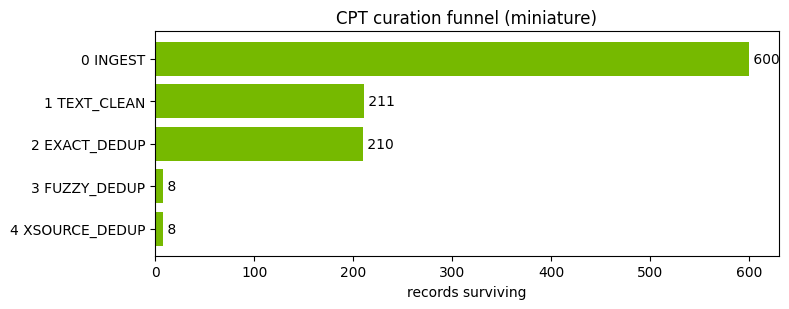

Kept 8/600 = 1% of ingested records
Curated CPT corpus -> data/final/cpt/  (consumed by M6 + M7)


In [13]:
# Code Cell 13 — Plot curation funnel
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from notebook_env import ensure

ensure("matplotlib", ["matplotlib"], quiet=True)

import matplotlib.pyplot as plt

labels = [name for name, _ in STAGE_STATS]
counts = [n for _, n in STAGE_STATS]
fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.barh(range(len(labels)), counts, color="#76B900")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("records surviving")
ax.set_title("CPT curation funnel (miniature)")
for b, n in zip(bars, counts):
    ax.text(b.get_width(), b.get_y() + b.get_height()/2, f" {n}", va="center")
plt.tight_layout()
plt.show()

print(f"Kept {counts[-1]}/{counts[0]} = {counts[-1]/max(counts[0],1):.0%} of ingested records")
print("Curated CPT corpus -> data/final/cpt/  (consumed by M6 + M7)")
